In [1]:
import numpy as np
import setup as stp
import Maxwell2D as Max
import mesh_reader as msh
import matplotlib.pyplot as plt

N = np.arange(1,9,1)
erros = []
for n in range(len(N)):
    VX, VY, EToV, BCTags = msh.MeshReader2D('malhas/pi.msh')

    malha = stp.StartUp2D(N[n],EToV,VX,VY)

    Ez = np.zeros((malha.Np,malha.K),dtype=np.float64)
    Ez = np.sin(malha.x)*np.sin(malha.y)
    Hx = np.zeros((malha.Np,malha.K), dtype=np.float64)
    Hy = np.zeros((malha.Np,malha.K),dtype= np.float64)

    #FinalTime = 3 * np.pi * np.sqrt(2)
    FinalTime = 5

    Hx, Hy, Ez, pp, t, erro = Max.Maxwell2D(Hx,Hy,Ez,FinalTime,malha,CFL=0.1,pml=False)

    Ez_analitico = np.sin(malha.x)*np.sin(malha.y)*np.cos(np.sqrt(2)*t[-1])

    M = np.linalg.inv(malha.V @ malha.V.T) 

    erro_nodal = Ez - Ez_analitico

    integral_erro_sq = np.sum(malha.J * (erro_nodal * (M @ erro_nodal)))
    En = np.sqrt(integral_erro_sq)

    integral_analitico_sq = np.sum(malha.J * (Ez_analitico * (M @ Ez_analitico)))
    wt = np.sqrt(integral_analitico_sq)

    erro_L2_real = En / wt

    erros.append(erro_L2_real)

Malha carregada com sucesso!
Número de vértices: 441
Número de Elementos (K): 800
Tempo atual: 3.5417e-02 / 5.0000e+00
Tempo atual: 7.0833e-02 / 5.0000e+00
Tempo atual: 1.0625e-01 / 5.0000e+00
Tempo atual: 1.4167e-01 / 5.0000e+00
Tempo atual: 1.7708e-01 / 5.0000e+00
Tempo atual: 2.1250e-01 / 5.0000e+00
Tempo atual: 2.4792e-01 / 5.0000e+00
Tempo atual: 2.8333e-01 / 5.0000e+00
Tempo atual: 3.1875e-01 / 5.0000e+00
Tempo atual: 3.5417e-01 / 5.0000e+00
Tempo atual: 3.8958e-01 / 5.0000e+00
Tempo atual: 4.2500e-01 / 5.0000e+00
Tempo atual: 4.6042e-01 / 5.0000e+00
Tempo atual: 4.9583e-01 / 5.0000e+00
Tempo atual: 5.3125e-01 / 5.0000e+00
Tempo atual: 5.6667e-01 / 5.0000e+00
Tempo atual: 6.0208e-01 / 5.0000e+00
Tempo atual: 6.3750e-01 / 5.0000e+00
Tempo atual: 6.7292e-01 / 5.0000e+00
Tempo atual: 7.0833e-01 / 5.0000e+00
Tempo atual: 7.4375e-01 / 5.0000e+00
Tempo atual: 7.7917e-01 / 5.0000e+00
Tempo atual: 8.1458e-01 / 5.0000e+00
Tempo atual: 8.5000e-01 / 5.0000e+00
Tempo atual: 8.8542e-01 / 5.00

Taxa de Convergência Espectral (Sigma):
De N=1 para N=2 -> taxa sigma = 3.31
De N=2 para N=3 -> taxa sigma = 3.55
De N=3 para N=4 -> taxa sigma = 3.58
De N=4 para N=5 -> taxa sigma = 3.73
De N=5 para N=6 -> taxa sigma = 3.80
De N=6 para N=7 -> taxa sigma = 3.96


Para N = 1 -> erro = 1.40e-02
Para N = 2 -> erro = 5.09e-04
Para N = 3 -> erro = 1.46e-05
Para N = 4 -> erro = 4.06e-07
Para N = 5 -> erro = 9.72e-09
Para N = 6 -> erro = 2.18e-10
Para N = 7 -> erro = 4.16e-12
Para N = 8 -> erro = 7.33e-13


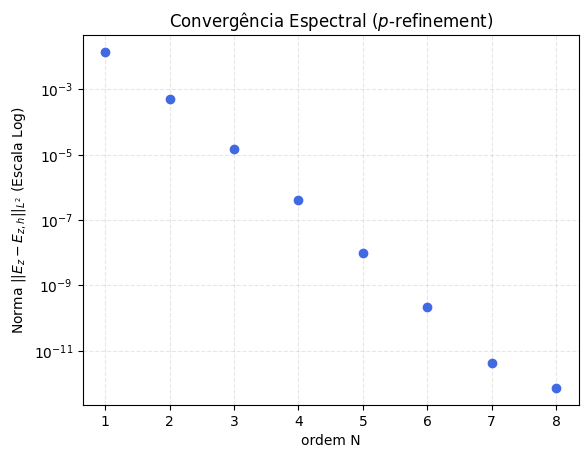

In [2]:
ordens_N = N
erros = np.array(erros)

print("Taxa de Convergência Espectral (Sigma):")
for i in range(len(ordens_N) - 2):
    N_antigo = ordens_N[i]
    N_novo = ordens_N[i+1]
    
    E_antigo = erros[i]
    E_novo = erros[i+1]
    
    sigma = - (np.log(E_novo) - np.log(E_antigo)) / (N_novo - N_antigo)
    
    print(f"De N={N_antigo} para N={N_novo} -> taxa sigma = {sigma:.2f}")

print('\n')
for j in range(len(N)):
    print(f'Para N = {N[j]} -> erro = {erros[j]:.2e}')

plt.figure()
plt.grid(alpha=0.3,ls='--')
plt.title(r'Convergência Espectral ($p$-refinement)')
plt.semilogy(N,erros,'o',color='royalblue')
plt.ylabel(r'Norma $||E_z-E_{z,h}||_{L^2}$ (Escala Log)')
plt.xlabel('ordem N')
plt.show()